In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

df = pd.read_csv('../data/cleaned/city_day_cleaned.csv')
print("✅ Data loaded:", df.shape)

✅ Data loaded: (24850, 21)


In [2]:
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
            'Benzene', 'Toluene', 'Year', 'Month', 'Day',
            'City_Encoded', 'Season_Encoded']
target = 'AQI'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (24850, 16)
Target shape: (24850,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (19880, 16) Test: (4970, 16)


In [4]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("--- Random Forest Results ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

--- Random Forest Results ---
MAE:  20.83
RMSE: 40.42
R²:   0.9108


In [5]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Results ---")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²:   {r2_xgb:.4f}")

--- XGBoost Results ---
MAE:  20.58
RMSE: 44.73
R²:   0.8908


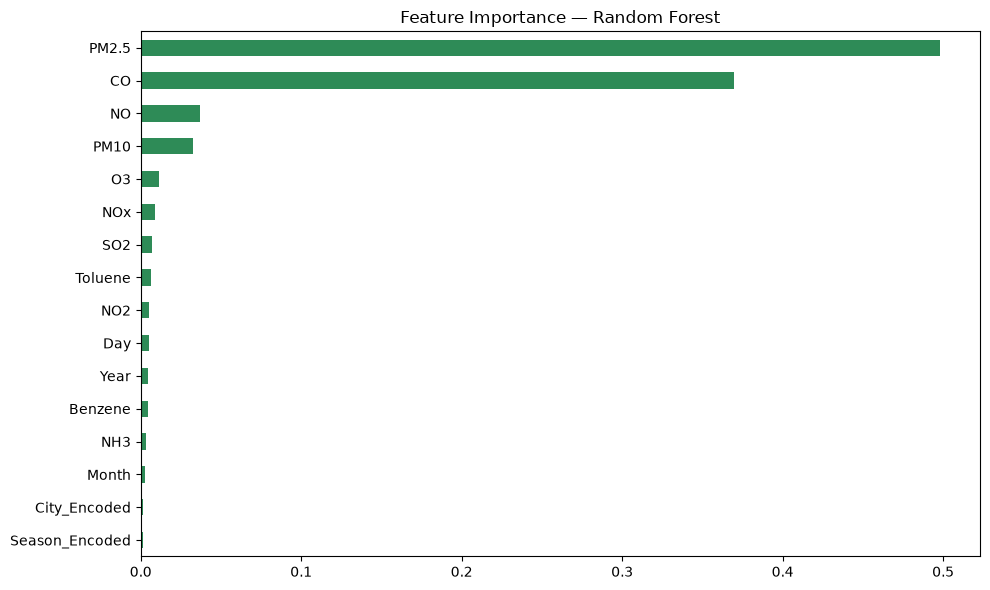

PM2.5             0.498073
CO                0.369506
NO                0.036981
PM10              0.032652
O3                0.011576
NOx               0.009147
SO2               0.007337
Toluene           0.006619
NO2               0.005348
Day               0.005018
Year              0.004535
Benzene           0.004413
NH3               0.003221
Month             0.002802
City_Encoded      0.001636
Season_Encoded    0.001136
dtype: float64


In [6]:
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='barh', color='seagreen')
plt.title('Feature Importance — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance)

In [7]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [mae, mae_xgb],
    'RMSE': [rmse, rmse_xgb],
    'R2 Score': [r2, r2_xgb]
})
print(results)
results.to_csv('../reports/model_comparison.csv', index=False)

           Model        MAE       RMSE  R2 Score
0  Random Forest  20.830869  40.418785  0.910782
1        XGBoost  20.581872  44.725174  0.890758


In [8]:
# Pick whichever has higher R2 — likely XGBoost
best_model = xgb_model if r2_xgb > r2 else rf_model
best_name = 'xgboost' if r2_xgb > r2 else 'random_forest'

joblib.dump(best_model, f'../models/aqi_{best_name}_model.pkl')
print(f"✅ Best model saved: {best_name}")

✅ Best model saved: random_forest
